 **DVI Lab Project
Air Pollution World wide dataset
Name- Sanchit Panwar
SAP ID- 500123669
Batch B9**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/air pollution dataset.csv")
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,newCountry
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,Russian Federation
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,Brazil
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,Italy
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,Poland
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,France


In [3]:
df.isnull().sum()


,0
Country,427
City,0
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


Filling missing values

In [4]:

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))


Remove Duplicate

In [5]:
df = df.drop_duplicates()


In [6]:
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

num_cols = df.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    df = remove_outliers_iqr(df, col)


Univariate Analysis

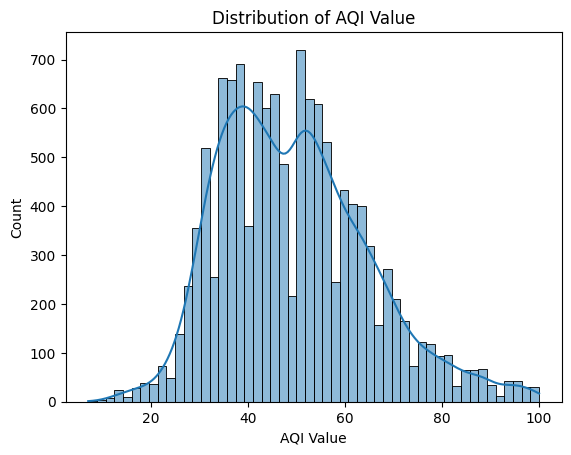

In [7]:
sns.histplot(df[num_cols[0]], kde=True)
plt.title("Distribution of " + num_cols[0])
plt.show()


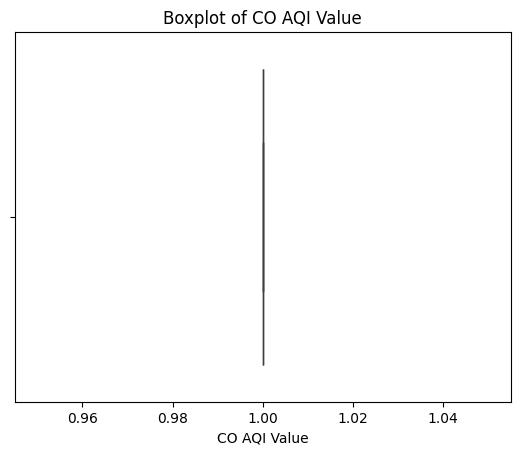

In [8]:
sns.boxplot(x=df[num_cols[1]])
plt.title("Boxplot of " + num_cols[1])
plt.show()


Bivariate Analysis

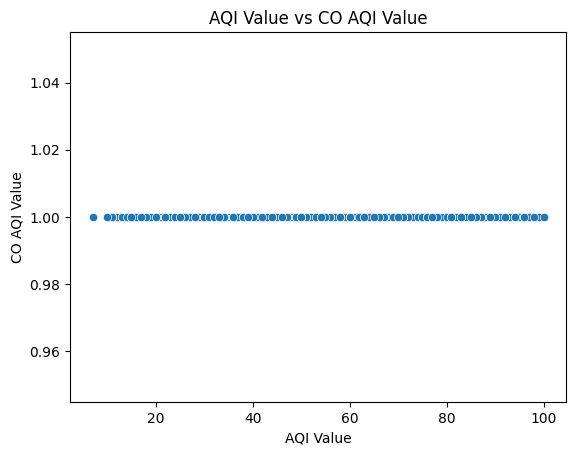

In [9]:
sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]])
plt.title(f"{num_cols[0]} vs {num_cols[1]}")
plt.show()


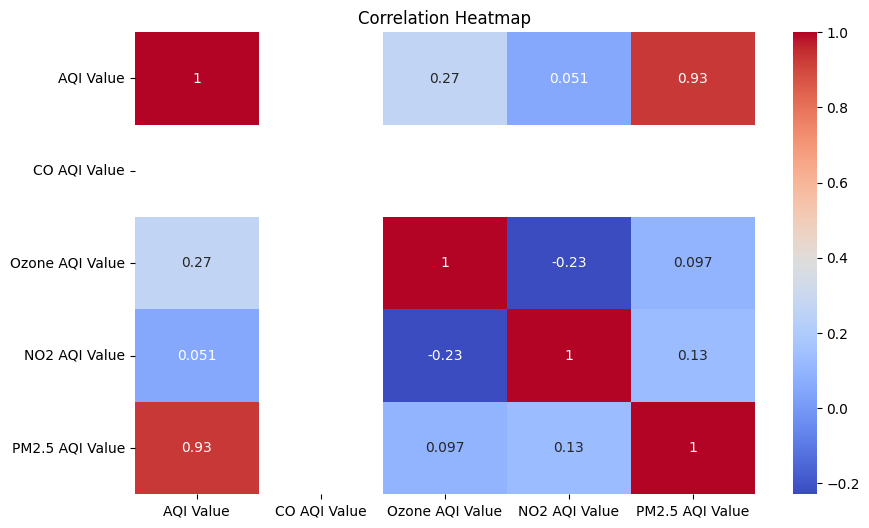

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Statistical Test Code:Chi-Square Test (Categorical vs Categorical)

In [11]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df[cat_cols[0]], df[cat_cols[1]])
chi2, p, dof, exp = chi2_contingency(table)

print("Chi2:", chi2)
print("P-value:", p)


Chi2: 1911300.0
P-value: 0.4692868858548075


Machine Learning Models

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [13]:
cat_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [14]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


K-MEANS CLUSTERING MODEL

In [15]:
features = df[num_cols].iloc[:, :4]   # first 4 numeric columns


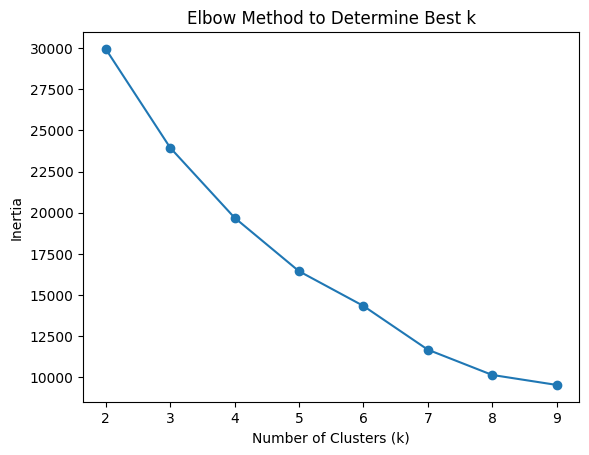

In [16]:
inertia = []
K = range(2,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method to Determine Best k")
plt.show()


In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features)


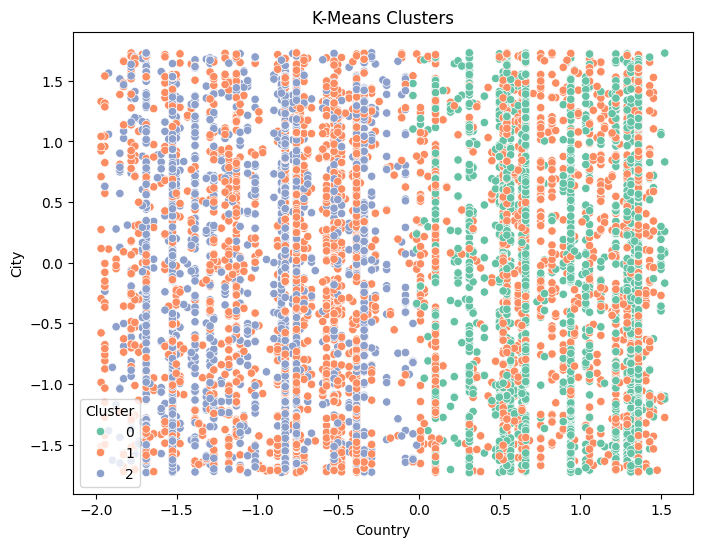

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=features.iloc[:,0],
    y=features.iloc[:,1],
    hue=df['Cluster'],
    palette='Set2'
)
plt.title("K-Means Clusters")
plt.show()


CLASSIFICATION MODEL (LOGISTIC REGRESSION)

In [19]:
target = "target_column_name"  # replace with your column


In [20]:
df.columns


Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category', 'newCountry', 'Cluster'],
      dtype='object')